# CAS Exam 5: Chain Ladder Method (Development Method)

This notebook uses real data from:
- `.../chainladder-python/chainladder/utils/data/friedland_us_industry_auto.csv`

Learning goals:
- Work directly with the `chainladder.Triangle` structure.
- Show age-to-age factors, candidate LDF selections, tail alternatives, and selected CDFs.
- Project ultimates and implied IBNR with explicit actuarial considerations.


## Formula Sheet Reference

### 7-Step Chain Ladder Process

| Step | Action |
|------|--------|
| 1 | Compile claims data into a triangle (cumulative paid **or** reported, by origin × development age) |
| 2 | Calculate **age-to-age development factors** for each origin year and each transition |
| 3 | Calculate **averages** of age-to-age factors: volume-weighted, simple (arithmetic), medial (trimmed), geometric |
| 4 | **Select** claim development factors (LDFs) for each development period |
| 5 | **Select a tail factor** — covers development beyond the oldest observed age |
| 6 | Calculate **cumulative development factors (CDFs)** by multiplying selected LDFs from each age to ultimate |
| 7 | **Project ultimate claims** = Latest Diagonal × CDF-to-ultimate |

### Key Relationships

$$\text{CDF}(d \to \text{ult}) = \text{LDF}(d \to d{+}1) \times \text{LDF}(d{+}1 \to d{+}2) \times \cdots \times \text{Tail}$$

$$\text{Ultimate} = \text{Latest} \times \text{CDF}(d \to \text{ult})$$

$$\text{IBNR} = \text{Ultimate} - \text{Latest} = \text{Latest} \times (\text{CDF} - 1)$$

$$\%\ \text{Paid at age } d = \frac{1}{\text{CDF}(d \to \text{ult})} \qquad \%\ \text{Unreported} = 1 - \frac{1}{\text{CDF}}$$

### Averaging Methods (Step 3)

- **Volume-weighted**: $\frac{\sum C_{w,d+1}}{\sum C_{w,d}}$ — weights by the prior-age value; most common selection
- **Simple (arithmetic)**: unweighted mean of all link ratios for that transition
- **Medial**: drop the single highest and lowest link ratio, then take the simple average of the rest
- **Geometric**: $\exp\!\left(\frac{1}{n}\sum \ln f_{w,d}\right)$ — less sensitive to outlier-high factors than arithmetic

### Key Assumptions

1. Future development will follow patterns consistent with observed history
2. Each accident year's observed claims at a given age contain information about its ultimate
3. The mix of business, claim handling, and external environment are sufficiently stable for historical patterns to transfer forward

In [30]:
from __future__ import annotations

from pathlib import Path
import sys

import chainladder as cl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from reservingengine.reserving import triangle_to_frame

DATA_PATH = ROOT / 'chainladder-python' / 'chainladder' / 'utils' / 'data' / 'friedland_us_industry_auto.csv'
raw = pd.read_csv(DATA_PATH)

raw.head()

,Accident Year,Calendar Year,Paid Claims,Reported Claims
0,1998,1998,18539254,37017487
1,1998,1999,33231039,43169009
2,1998,2000,40062008,45568919
3,1998,2001,43892039,46784558
4,1998,2002,45896535,47337318


*Initial Data Requirements*:
* Tabular data with:
    * one origin field (Accident Year)
    * one development (or valuation) field (Calendar Year)
    * one or more value columns (Paid Claims, Reported Claims)
* Data may be incremental or cumulative.
* Optional: one or more segment/index fields. (e.g. LOBs. Only auto data is used in this example)

## Step 1: Compile Data in `chainladder.Triangle` Form

The object below is the actual chainladder triangle structure used for all downstream calculations.    
*Structure*  
* 4D object: [index, columns, origin, development]  
    * index = segment keys (e.g., LOB, state, company); can be multi-level  
    * columns = measures (Paid, Incurred, Counts, Exposure, etc.)  
    * origin = accident/policy/report year (or period)  
    * development = development age (or valuation period)  


*Think of it as a labeled actuarial data cube with reserving semantics layered on top of pandas-like behavior.*


In [31]:
triangle = cl.Triangle(
    raw,
    origin='Accident Year',
    development='Calendar Year',
    columns=['Paid Claims', 'Reported Claims'],
    cumulative=True,
)
triangle

,Triangle Summary
Valuation:,2007-12
Grain:,OYDY
Shape:,"(1, 2, 10, 10)"
Index:,[Total]
Columns:,"[Paid Claims, Reported Claims]"


In [32]:
paid_triangle = triangle['Paid Claims']
reported_triangle = triangle['Reported Claims']
paid_triangle

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",
2000,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,
2001,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,
2002,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,
2003,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654",,,,,
2004,"24,369,770","41,489,863","49,236,678","53,774,672",,,,,,
2005,"25,100,697","42,702,229","50,644,994",,,,,,,
2006,"25,608,776","43,606,497",,,,,,,,
2007,"27,229,969",,,,,,,,,


In [63]:
paid_triangle.shift(1)

,12,24,36,48,60,72,84,96,108,120
1998,"33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187",0
1999,"36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",,
2000,"38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,,
2001,"40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,,
2002,"41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,,
2003,"41,399,612","49,070,332","53,584,201","55,930,654",,,,,,
2004,"41,489,863","49,236,678","53,774,672",,,,,,,
2005,"42,702,229","50,644,994",,,,,,,,
2006,"43,606,497",,,,,,,,,
2007,,,,,,,,,,


In [33]:
print("Origin:", paid_triangle.origin) # origin axis values
print("Development Ages:", paid_triangle.development.values) # development ages
print("Valuation Date:", paid_triangle.valuation_date) # latest valuation date of the triangle
print("Columns:", paid_triangle.columns) # measure names
print("Index:", paid_triangle.index) # segment keys. Default is Total
# index and slice triangles similar to pandas, but 4d
print("Shape:", paid_triangle.shape) # (index, values, number of origin periods, number of development ages)
print("Is Cumulative:", paid_triangle.is_cumulative) # indicates cumulative vs incremental

Origin: PeriodIndex(['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
             '2006', '2007'],
            dtype='period[Y-DEC]', name='origin')
Development Ages: [ 12  24  36  48  60  72  84  96 108 120]
Valuation Date: 2007-12-31 23:59:59.999999999
Columns: Index(['Paid Claims'], dtype='object', name='columns')
Index:    Total
0  Total
Shape: (1, 1, 10, 10)
Is Cumulative: True


In [34]:
print("Latest Diagonal:") 
paid_triangle.latest_diagonal # most recent observed values

Latest Diagonal:


,2007
1998,"47,644,187"
1999,"51,000,534"
2000,"54,533,225"
2001,"55,878,421"
2002,"57,807,215"
2003,"55,930,654"
2004,"53,774,672"
2005,"50,644,994"
2006,"43,606,497"
2007,"27,229,969"


In [35]:
paid_triangle.describe()

,12,24,36,48,60,72,84,96,108,120
count,10.00,9.00,8.00,7.00,6.00,5.00,4.00,3.00,2.00,1.00
mean,"23,454,899.40","39,931,938.78","47,041,791.75","50,774,191.14","52,481,468.83","52,770,716.40","52,002,458.50","50,952,970.00","49,277,995.00","47,644,187.00"
std,"2,553,140.80","3,350,901.21","3,666,127.53","3,914,173.00","4,191,283.90","4,358,235.53","3,872,321.20","3,543,756.06","2,436,038.02",NaN
min,"18,539,254.00","33,231,039.00","40,062,008.00","43,892,039.00","45,896,535.00","46,765,422.00","47,221,322.00","47,446,877.00","47,555,456.00","47,644,187.00"
25%,"22,338,697.00","38,976,014.00","45,606,812.00","48,860,813.00","50,090,219.00","50,162,043.00","49,774,648.25","49,162,842.50","48,416,725.50","47,644,187.00"
50%,"24,088,616.50","41,399,612.00","48,419,083.50","52,093,916.00","53,549,358.00","53,740,101.00","52,455,045.50","50,878,808.00","49,277,995.00","47,644,187.00"
75%,"24,917,965.25","41,795,313.00","49,403,459.25","53,679,436.50","55,538,849.50","55,378,801.00","54,682,855.75","52,706,016.50","50,139,264.50","47,644,187.00"
max,"27,229,969.00","43,606,497.00","50,644,994.00","54,352,884.00","56,754,376.00","57,807,215.00","55,878,421.00","54,533,225.00","51,000,534.00","47,644,187.00"


In [64]:
# paid_triangle.groupby("LOB").sum()
# groupby — works on the index axis (dim 0), which requires a multi-row index. 
# #The Friedland dataset is a single-entity triangle (shape[0] = 1), 
#   so groupby does nothing useful there.

In [62]:
paid_triangle.grain("OYDY")

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",
2000,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,
2001,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,
2002,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,
2003,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654",,,,,
2004,"24,369,770","41,489,863","49,236,678","53,774,672",,,,,,
2005,"25,100,697","42,702,229","50,644,994",,,,,,,
2006,"25,608,776","43,606,497",,,,,,,,
2007,"27,229,969",,,,,,,,,


In [66]:
(paid_triangle / reported_triangle).heatmap()

,12,24,36,48,60,72,84,96,108,120
1998,0.5008,0.7698,0.8792,0.9382,0.9696,0.9838,0.9913,0.9949,0.9965,0.9979
1999,0.5239,0.7838,0.8850,0.9391,0.9700,0.9850,0.9913,0.9944,0.9964,
2000,0.5375,0.7894,0.8860,0.9402,0.9711,0.9846,0.9916,0.9944,,
2001,0.5423,0.7927,0.8895,0.9446,0.9726,0.9861,0.9925,,,
2002,0.5383,0.7890,0.8895,0.9419,0.9724,0.9866,,,,
2003,0.5333,0.7886,0.8847,0.9398,0.9716,,,,,
2004,0.5366,0.7882,0.8863,0.9438,,,,,,
2005,0.5414,0.7939,0.8919,,,,,,,
2006,0.5497,0.7980,,,,,,,,
2007,0.5574,,,,,,,,,


In [36]:
print("Paid Losses for every maturity of first 3 origin periods :\n")
paid_triangle.values[0, 0, :3, :] # underlying numpy array 

Paid Losses for every maturity of first 3 origin periods :



array([[18539254., 33231039., 40062008., 43892039., 45896535., 46765422.,
        47221322., 47446877., 47555456., 47644187.],
       [20410193., 36090684., 43259402., 47159241., 49208532., 50162043.,
        50625757., 50878808., 51000534.,       nan],
       [22120843., 38976014., 46389282., 50562385., 52735280., 53740101.,
        54284334., 54533225.,       nan,       nan]])

In [37]:
paid_triangle.heatmap()

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",
2000,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,
2001,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,
2002,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,
2003,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654",,,,,
2004,"24,369,770","41,489,863","49,236,678","53,774,672",,,,,,
2005,"25,100,697","42,702,229","50,644,994",,,,,,,
2006,"25,608,776","43,606,497",,,,,,,,
2007,"27,229,969",,,,,,,,,


<Axes: >

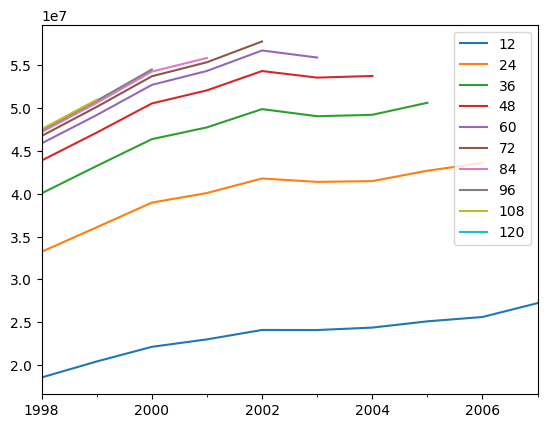

In [38]:
paid_triangle.plot()

In [39]:
paid_triangle.dev_to_val()

,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534"
2000,,,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225"
2001,,,,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421"
2002,,,,,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215"
2003,,,,,,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654"
2004,,,,,,,"24,369,770","41,489,863","49,236,678","53,774,672"
2005,,,,,,,,"25,100,697","42,702,229","50,644,994"
2006,,,,,,,,,"25,608,776","43,606,497"
2007,,,,,,,,,,"27,229,969"


In [40]:
paid_triangle.cum_to_incr()

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","14,691,785","6,830,969","3,830,031","2,004,496","868,887","455,900","225,555","108,579","88,731"
1999,"20,410,193","15,680,491","7,168,718","3,899,839","2,049,291","953,511","463,714","253,051","121,726",
2000,"22,120,843","16,855,171","7,413,268","4,173,103","2,172,895","1,004,821","544,233","248,891",,
2001,"22,992,259","17,103,939","7,671,637","4,326,081","2,269,520","1,015,365","499,620",,,
2002,"24,092,782","17,702,531","8,108,490","4,449,081","2,401,492","1,052,839",,,,
2003,"24,084,451","17,315,161","7,670,720","4,513,869","2,346,453",,,,,
2004,"24,369,770","17,120,093","7,746,815","4,537,994",,,,,,
2005,"25,100,697","17,601,532","7,942,765",,,,,,,
2006,"25,608,776","17,997,721",,,,,,,,
2007,"27,229,969",,,,,,,,,


**Reading incremental data:** Incremental claims show how much development occurred *within each calendar year* (each diagonal). Three things to look for:

- **Diagonal spikes** — unusually large incremental amounts for one calendar year that appear across multiple origin years (same column in the incremental triangle) suggest a systemwide event: superimposed inflation, a legal change, or a shift in claims handling. This is the visual signal that the L/S calendar-year test below formalises.
- **Heavy late-age increments** — if the oldest development periods still show material payments, the tail factor matters significantly and a 1.000 tail would understate ultimates.
- **Near-zero late increments** — if the last few development ages are essentially zero, the line is nearly fully developed within the triangle and a tail close to 1.000 is defensible.

## Step 2: Age-to-Age Factors and Pattern Diagnostics

We inspect link ratios by AY. Educationally, this is where we look for trend, volatility, and possible structural shifts.
If early-age factors are drifting down or up over time, that influences selection of recent vs all-year averages.


In [41]:
age_to_age = paid_triangle.link_ratio
age_to_age.heatmap()


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
1998,1.7925,1.2056,1.0956,1.0457,1.0189,1.0097,1.0048,1.0023,1.0019
1999,1.7683,1.1986,1.0902,1.0435,1.0194,1.0092,1.0050,1.0024,
2000,1.7620,1.1902,1.0900,1.0430,1.0191,1.0101,1.0046,,
2001,1.7439,1.1913,1.0906,1.0436,1.0187,1.0090,,,
2002,1.7348,1.1940,1.0892,1.0442,1.0186,,,,
2003,1.7189,1.1853,1.0920,1.0438,,,,,
2004,1.7025,1.1867,1.0922,,,,,,
2005,1.7012,1.1860,,,,,,,
2006,1.7028,,,,,,,,


### Full Age-to-Age Factor Exhibit (Friedland Style — Step 2 / Step 3)

The heatmap above gives a visual read; the exhibit below gives the numbers. This is the standard Friedland presentation: every individual link ratio by accident year, with the four formula-sheet averages appended as summary rows.

> **Formula sheet note** — Exam questions can ask you to compute any of the four averaging methods from a factor table, or to identify which average a given set of numbers represents. The table below shows all four for every development period side by side.

In [42]:
from reservingengine.reserving import link_ratio_table

# Full Friedland-style exhibit: individual link ratios + Vol Wtd / Simple / Medial / Selected rows
lr_exhibit = link_ratio_table(paid_triangle, n_periods=-1)
lr_exhibit

,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
origin,,,,,,,,,
1998,1.79,1.21,1.10,1.05,1.02,1.01,1.00,1.00,1.00
1999,1.77,1.20,1.09,1.04,1.02,1.01,1.00,1.00,NaN
2000,1.76,1.19,1.09,1.04,1.02,1.01,1.00,NaN,NaN
2001,1.74,1.19,1.09,1.04,1.02,1.01,NaN,NaN,NaN
2002,1.73,1.19,1.09,1.04,1.02,NaN,NaN,NaN,NaN
2003,1.72,1.19,1.09,1.04,NaN,NaN,NaN,NaN,NaN
2004,1.70,1.19,1.09,NaN,NaN,NaN,NaN,NaN,NaN
2005,1.70,1.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,1.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Geometric average — not built into chainladder Development, so computed manually.
# Formula: exp(mean of log link-ratios), which is less pulled by outlier-high factors than arithmetic.

lr_frame = age_to_age.to_frame()   # individual link ratios: origins × transitions
geo_avg = pd.Series(
    np.exp(np.log(lr_frame.clip(lower=1e-8)).mean()),
    name='Geometric Avg',
    dtype=float,
)

print("Geometric averages by development period:")
geo_avg.to_frame().T

NameError: name 'np' is not defined

Here is a clean, exam-ready markdown commentary you can paste directly into your notebook.

---

### Commentary on the 12–24 Age-to-Age Factors (Accident Years 1998–2006)

The 12–24 development factors show a **general downward trend across accident years**, with relatively small year-to-year fluctuations.

#### 1. Observed Pattern

* Earlier accident years (e.g., 1998–1999) exhibit higher 12–24 factors.
* More recent accident years show gradually smaller factors.
* The year-over-year change is modest and mostly negative.
* There are no extreme spikes or volatility.

This indicates a **smooth declining pattern** rather than random instability.

---

### 2. Interpretation of a Decreasing 12–24 Factor

The 12–24 factor reflects the amount of development occurring between the first and second year after accident.

A decreasing factor over time may suggest:

* **Faster claim reporting or settlement** in more recent years.
* Improved claims handling or operational efficiency.
* Shifts in case reserving philosophy.
* A reduction in late-reported claims.
* Structural changes in mix of business.

The key actuarial question is:

> Is this trend structural (permanent change) or random fluctuation?

---

### 3. Relevance for Development Method Assumptions

The Chain Ladder method assumes:

* Development patterns are stable over time.
* Future development will resemble historical development.

A consistent downward drift may indicate:

* Violation of strict stationarity.
* A possible calendar year or operational effect.
* A change in reporting speed.

This does **not automatically invalidate Chain Ladder**, but it requires judgment.

---

### 4. Factor Selection Considerations (Exam Perspective)

When selecting the 12–24 factor, several approaches may be considered:

#### Option A: Volume-Weighted Average

* Appropriate if trend is modest and data is credible.
* Smooths minor fluctuations.
* Most commonly used default.

#### Option B: Simple or Recent Average

* May be appropriate if operational changes suggest older years are not representative.
* More weight on recent accident years.

#### Option C: Exclude Early Accident Years

* If earlier high factors are believed to reflect outdated claims practices.
* Common exam scenario: "process change occurred in year X."

#### Option D: Trend Adjustment

* If a structural acceleration in reporting is believed permanent,
  projecting a slightly lower factor may be justified.

---

### 5. Stability and Credibility Assessment

Indicators supporting use of traditional Chain Ladder:

* Smooth progression.
* No extreme volatility.
* Changes are gradual rather than abrupt.
* No obvious outliers.

Indicators suggesting caution:

* Systematic monotonic decline.
* Known operational change during period.
* Evidence of valuation correlation.

---

### 6. Potential Exam Questions Based on This Pattern

If presented with this table, typical questions might include:

* Is the 12–24 factor stable?
* Should earlier accident years be excluded?
* Is there evidence of a change in settlement speed?
* How would faster reporting affect ultimates?
* Would the development method overstate or understate ultimates if the trend continues?
* How would this impact Bornhuetter–Ferguson?
* Would valuation correlation likely detect this?

---

### 7. Impact on Ultimate Estimates

If more recent years truly develop less between 12–24:

* Using older higher factors may **overstate ultimates**.
* Using only recent lower factors may reduce projected development.
* Choice of selected factor materially affects immature accident years.

Since 12–24 is an early maturity period, its selection significantly impacts:

* Young accident years
* IBNR estimates
* Sensitivity of ultimates

In [ ]:
first_factor = age_to_age.to_frame()['12-24'].dropna().to_frame(name='12-24')
first_factor['ChangeFromPriorAY'] = first_factor['12-24'].diff()
first_factor

,12-24,ChangeFromPriorAY
1998,1.792469,NaN
1999,1.768268,-0.024201
2000,1.761959,-0.006309
2001,1.743900,-0.018059
2002,1.734765,-0.009135
2003,1.718935,-0.015830
2004,1.702514,-0.016422
2005,1.701237,-0.001277
2006,1.702795,0.001558


This uses chainladder's Mack-style diagnostics (not exam-5):  
- `DevelopmentCorrelation` for serial/development-period correlation.
    * H_0: Independence between successive development factors (rejected)
- `ValuationCorrelation` for calendar-year/valuation effects.  

In [ ]:
development_corr = cl.DevelopmentCorrelation(paid_triangle, p_critical=0.5)
valuation_corr = cl.ValuationCorrelation(paid_triangle, p_critical=0.1, total=True)

valuation_z = float(valuation_corr.z.iloc[0, 0]) if hasattr(valuation_corr.z, "iloc") else float(valuation_corr.z)
valuation_flag = bool(valuation_corr.z_critical.iloc[0, 0]) if hasattr(valuation_corr.z_critical, "iloc") else bool(valuation_corr.z_critical)

correlation_summary = pd.DataFrame(
    [
        {
            'DevelopmentCorrReject': bool(development_corr.reject),
            'Development_p_critical': development_corr.p_critical,
            'ValuationZ': valuation_z,
            'ValuationCorrFlag': valuation_flag,
            'Valuation_p_critical': valuation_corr.p_critical,
        }
    ]
)

correlation_summary


,DevelopmentCorrReject,Development_p_critical,ValuationZ,ValuationCorrFlag,Valuation_p_critical
0,True,0.5,13.0,False,0.1


Development Correlation Test: Reject the null
*Translation:*
* Adjacent development periods are correlated.  
* The Mack independence assumption is violated.  
* Development factors are not independent across columns.  

This affects:  
* Mack standard error estimates  
* Variance calculations  
* Confidence intervals   
* *It does not automatically invalidate point estimates, but it weakens the statistical assumptions behind the model.*  

Why this matters  
* If development factors are correlated: 
    * Variance estimates are understated.  
    * The triangle may have structural effects.  
*You should be cautious interpreting Mack results.*

The valuation correlation test does not indicate significant calendar-year effects, suggesting the core Chain Ladder assumption that development depends only on age is not materially violated.

### Calendar Year / Diagonal Effects — L/S Test (Friedland Chapter 8)

The `ValuationCorrelation` test above gives a statistical flag. The **L/S test** gives the intuition behind it.

**How it works:**
1. For each development period (column), compute the column's median link ratio.
2. Label every individual link ratio "**L**" if it is above the median, "**S**" if at or below.
3. For each calendar year (diagonal), count the L's and S's across all development periods active in that year.
4. A year with predominantly L's had above-average development across the board — possible superimposed inflation, a favourable legal year, or a claims-handling change.  A year with predominantly S's had the reverse.

A calendar year is flagged as unusual if it is consistently skewed.  This is complementary to the statistical test: the test tells you *whether* an effect exists; the table below tells you *which year(s)* to investigate.

In [ ]:
from reservingengine.reserving import calendar_year_diagnostic

cy_diag = calendar_year_diagnostic(paid_triangle)

# L/S matrix: 'L' = factor above column median, 'S' = at or below
# Read along diagonals (top-right to bottom-left) to see calendar years
print("L/S matrix — read diagonals to identify calendar year effects:")
cy_diag['ls_matrix']

In [ ]:
# Calendar year summary: count of L and S labels per diagonal year
# pct_L near 0.75+ = above-average development year; near 0.25- = below-average
print("Calendar year summary:")
cy_diag['calendar_year_summary']

### Paid vs Reported (Incurred) Development Comparison

Both triangles were loaded in Step 1 but only paid is used for the main projection. Comparing paid and reported development patterns is a standard diagnostic before committing to either:

- **Paid LDFs > Reported LDFs** at the same age: paid is developing faster than reported, which means case reserves are being paid down quickly. Paid development can be more volatile if settlement rates shift.
- **Paid LDFs < Reported LDFs**: reported grows faster than paid — case reserves are building up faster than they're being paid, possibly signaling case reserve strengthening.
- **Paid/Incurred ratio at latest diagonal** should approach **1.0** for mature accident years. For immature years, a ratio well below 1.0 is expected (significant case reserves still outstanding). A ratio *above* 1.0 is a data error.

> **Exam connection** — Berquist-Sherman adjustments are motivated by exactly this comparison. When case reserve adequacy changes over time, it distorts reported development patterns and you must adjust the triangle before applying the development method.  If case reserves increase (decrease) in adequacy, reported LDFs are artificially depressed (inflated).

In [ ]:
from reservingengine.reserving import paid_vs_incurred_comparison

pi_comp = paid_vs_incurred_comparison(paid_triangle, reported_triangle)

# Side-by-side selected LDFs + ratio column (paid LDF / reported LDF)
# Values < 1.0 mean paid develops faster than reported at that age
print("LDF comparison — paid vs reported, with ratio (paid/reported):")
pi_comp['ldf_comparison']

In [ ]:
# CDF comparison: paid vs reported CDFs to ultimate
# Paid CDF / Reported CDF > 1 means paid has more development remaining (higher leverage)
print("CDF-to-ultimate comparison — paid vs reported:")
pi_comp['cdf_comparison']

In [ ]:
# Paid/incurred ratio at the latest diagonal by accident year.
# Mature years (oldest AYs) should be near 1.0.
# Recent years are expected to be lower — large case reserves still outstanding.
# A ratio persistently below 1.0 even for mature years may suggest case reserves
# are building, which would inflate reported development factors.
print("Paid / incurred ratio at latest diagonal:")
pi_comp['paid_to_incurred_latest']

## Steps 3-4: Candidate LDF Sets and Selected Pattern

Candidate sets shown below:
- `simple_all_periods` — arithmetic (simple) average of all link ratios
- `volume_all_periods` — volume-weighted average of all years (formula-sheet standard)
- `regression_all_periods` — OLS regression through the origin
- `volume_recent_5` — volume-weighted average of the 5 most recent years

Additional averages computed separately (not built into `cl.Development`):
- **Geometric** — `exp(mean of log link-ratios)`; formula sheet lists this explicitly
- **Medial** — drop highest and lowest, then simple-average the rest; formula sheet lists this explicitly

Selection used here for teaching: recent-5 volume for the first two intervals (where trend pressure is highest), then all-year volume for later intervals (where credibility is lower and stability matters).

Note: for chainladder-python (as with sklearn), `.fit()` stores the parameters & attributes (`.ultimate_`, `.ibnr_`, `.latest_diagonal`) expose results

In [ ]:
candidate_specs = {
    'simple_all_periods': {'average': 'simple', 'n_periods': -1},
    'volume_all_periods': {'average': 'volume', 'n_periods': -1},
    'regression_all_periods': {'average': 'regression', 'n_periods': -1},
    'volume_recent_5': {'average': 'volume', 'n_periods': 5},
}

candidate_models = {name: cl.Development(**spec).fit(paid_triangle) for name, spec in candidate_specs.items()}
ldf_comparison = pd.DataFrame({name: model.ldf_.to_frame().iloc[0] for name, model in candidate_models.items()}).T

selected_average = ['volume'] * ldf_comparison.shape[1]
selected_n_periods = [5, 5] + [-1] * (ldf_comparison.shape[1] - 2)
selected_dev_model = cl.Development(average=selected_average, n_periods=selected_n_periods).fit(paid_triangle)
selected_ldf = selected_dev_model.ldf_.to_frame().iloc[0]

ldf_comparison.loc['selected_hybrid'] = selected_ldf
ldf_comparison


,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
simple_all_periods,1.736316,1.192216,1.091369,1.043940,1.018918,1.009535,1.004787,1.002340,1.001866
volume_all_periods,1.733500,1.191758,1.091283,1.043906,1.018904,1.009529,1.004782,1.002342,1.001866
regression_all_periods,1.730925,1.191343,1.091208,1.043878,1.018890,1.009523,1.004777,1.002344,1.001866
volume_recent_5,1.711825,1.188644,1.090772,1.043606,1.018904,1.009529,1.004782,1.002342,1.001866
selected_hybrid,1.711825,1.188644,1.091283,1.043906,1.018904,1.009529,1.004782,1.002342,1.001866


In [ ]:
# Extend the comparison with the two formula-sheet averages not built into cl.Development:
# geometric and medial.  These use the same link ratios already computed in Step 2.

# Geometric: exp(mean of log link-ratios)
geo_row = pd.Series(
    np.exp(np.log(lr_frame.clip(lower=1e-8)).mean()),
    dtype=float,
)

# Medial: from the exhibit already computed above (drop highest + lowest, then simple-average)
medial_row = lr_exhibit.loc['Medial Avg']

ldf_comparison_all = ldf_comparison.copy()
ldf_comparison_all.loc['geometric_all_periods'] = geo_row
ldf_comparison_all.loc['medial_all_periods']    = medial_row.values

print("All six candidate LDF sets including formula-sheet geometric and medial averages:")
ldf_comparison_all

Volume-weighted averages were selected due to their credibility and stability. Early maturities show modest downward drift in recent years; therefore, recent-year experience was emphasized for immature ages. Later maturities are stable across methods, so all-period volume-weighted averages were deemed appropriate. The selected factors produce a smooth progression and reflect both historical credibility and recent experience.

## Step 5: Tail Factor Choices

Three practical tail views demonstrated:
- Industry benchmark constant tail (1.010).
- Data-fitted `TailCurve` from the selected developed triangle.
- Paid-vs-reported proxy using mature AY latest reported/paid relationship.

No single tail is universally correct; appropriateness depends on line behavior, maturity, and external benchmark support.


**Short-tail vs long-tail context for tail factor selection:**

| Line type | Typical tail range | Notes |
|-----------|-------------------|-------|
| Short-tail (PD, homeowners, auto physical damage) | 1.000–1.005 | Triangle usually 95%+ developed within 3–5 years; tail is rarely material |
| Medium-tail (auto liability, GL small claims) | 1.005–1.030 | Some residual IBNR from late-reported or reopened claims |
| Long-tail (workers comp, med-mal, excess/umbrella) | 1.05–1.30+ | Tail can be the **single largest source of reserve uncertainty**; a 0.01 error in the tail factor has the same dollar impact as a 0.01 error in every selected LDF combined |

**When the tail matters most:**
- The oldest triangle age is still materially developing (less than ~85% reported at last age)
- The line has slow-settling bodily-injury or liability claims  
- Data is sparse at late ages, making curve extrapolation unreliable (TailCurve's weakness)
- External benchmarks differ materially from the data-fitted curve (suggests the data may not yet show full late-age emergence)

In [ ]:
selected_dev_triangle = selected_dev_model.transform(paid_triangle)
tail_curve_model = cl.TailCurve().fit(selected_dev_triangle) # extrapolate development beyond final maturity
tail_curve_factor = float(tail_curve_model.tail_.iloc[0, 0]) # extract tail factor from model

In [ ]:
tail_curve_factor

1.0011056328627517

In [ ]:
tail_curve_model

,curve,'exponential'
,fit_period,"(None, ...)"
,extrap_periods,100
,errors,'ignore'
,attachment_age,None
,reg_threshold,"(1.00001, ...)"
,projection_period,12


In [ ]:


#set up matrices for reported vs paid ratio analysis at mature ages
paid_long = triangle_to_frame(paid_triangle, origin_as_datetime=False).reset_index()
reported_long = triangle_to_frame(reported_triangle, origin_as_datetime=False).reset_index()
paid_matrix = paid_long.pivot(index='origin', columns='development', values='Paid Claims').sort_index().sort_index(axis=1)
reported_matrix = reported_long.pivot(index='origin', columns='development', values='Reported Claims').sort_index().sort_index(axis=1)

latest_age = paid_matrix.notna().iloc[:, ::-1].idxmax(axis=1)
mature_mask = latest_age >= 96

# get reported/paid ratio at mature ages 
mature_ratio = (reported_matrix.max(axis=1) / paid_matrix.max(axis=1)).where(mature_mask)
reported_paid_proxy_tail = float(mature_ratio.mean())

tail_candidates = pd.DataFrame(
    {
        'TailFactor': {
            'NoTail_1.000': 1.000,
            'IndustryBenchmark_example': 1.010,
            'TailCurve_FromData': tail_curve_factor,
            'MatureReportedPaidProxy': reported_paid_proxy_tail,
        },
        'Consideration': {
            'NoTail_1.000': 'Only reasonable if practically fully developed by 120 months.',
            'IndustryBenchmark_example': 'External benchmark; useful when data is sparse or noisy.',
            'TailCurve_FromData': 'Data-driven fit; sensitive when tail history is sparse.',
            'MatureReportedPaidProxy': 'Good if paid-vs-reported have stable relationship at mature ages.',
        },
    }
)
tail_candidates


,TailFactor,Consideration
NoTail_1.000,1.000000,Only reasonable if practically fully developed...
IndustryBenchmark_example,1.010000,External benchmark; useful when data is sparse...
TailCurve_FromData,1.001106,Data-driven fit; sensitive when tail history i...
MatureReportedPaidProxy,1.003760,Good if paid-vs-reported have stable relations...


## Steps 6-7: Selected CDFs, Ultimate, and IBNR

First, compare total ultimate/IBNR sensitivity across tail choices.
Then select one tail assumption for the final AY-level projection table.


In [ ]:
sensitivity_rows = []
for label, row in tail_candidates.iterrows():
    tail_factor = float(row['TailFactor'])
    tailed = cl.TailConstant(tail=tail_factor).fit_transform(selected_dev_triangle)
    model = cl.Chainladder().fit(tailed)
    sensitivity_rows.append(
        {
            'TailOption': label,
            'TailFactorUsed': tail_factor,
            'TotalLatest': float(tailed.latest_diagonal.sum()),
            'TotalUltimate': float(model.ultimate_.sum()),
            'TotalIBNR': float(model.ibnr_.sum()),
        }
    )

tail_sensitivity = pd.DataFrame(sensitivity_rows).set_index('TailOption').sort_values('TotalUltimate')

tail_sensitivity


,TailFactorUsed,TotalLatest,TotalUltimate,TotalIBNR
TailOption,,,,
NoTail_1.000,1.000000,498050368.0,5.717564e+08,7.370600e+07
TailCurve_FromData,1.001106,498050368.0,5.723885e+08,7.433815e+07
MatureReportedPaidProxy,1.003760,498050368.0,5.739060e+08,7.585558e+07
IndustryBenchmark_example,1.010000,498050368.0,5.774739e+08,7.942356e+07


In [ ]:
selected_tail_label = 'IndustryBenchmark_example' # choose based on considerations and sensitivity results
selected_tail_factor = float(tail_candidates.loc[selected_tail_label, 'TailFactor'])

selected_tail_model = cl.TailConstant(tail=selected_tail_factor).fit(selected_dev_triangle)
selected_tail_model

,tail,1.01
,decay,0.5
,attachment_age,None
,projection_period,12


In [ ]:
selected_tail_model.cdf_

,12-Ult,24-Ult,36-Ult,48-Ult,60-Ult,72-Ult,84-Ult,96-Ult,108-Ult,120-Ult,132-Ult
(All),2.4299,1.4195,1.1942,1.0943,1.0483,1.0288,1.0191,1.0143,1.0119,1.0100,1.0050


### How CDFs Are Built from Selected LDFs (Step 6)

The CDF for any development age is the **right-to-left cumulative product** of all future LDFs from that age onward, including the tail:

$$\text{CDF}(d \to \text{ult}) = \underbrace{\text{LDF}(d \to d{+}1)}_{\text{next age}} \times \underbrace{\text{LDF}(d{+}1 \to d{+}2)}_{\cdots} \times \cdots \times \underbrace{\text{Tail}}_{\text{beyond last age}}$$

The table below shows the chain explicitly — each row is a development age, and the CDF in that row is the product of all LDFs from that age through ultimate.

> **Exam tip** — `% paid = 1/CDF` is the single most important derived quantity. It tells you how developed each accident year currently is and it appears in the BF formula: `IBNR = Expected Claims × % Unreported = Expected Claims × (1 − 1/CDF)`. A recent AY with a large CDF (small `% paid`) is highly leveraged — small changes in LDF selection produce large changes in IBNR.

In [ ]:
# Build the LDF→CDF chain explicitly to show the Step 6 multiplication.
# selected_ldf is the hybrid LDF series from the candidate comparison above.
# selected_tail_factor is the chosen tail from Step 5.

ldf_values  = selected_ldf.values.tolist()
transitions = selected_ldf.index.tolist()      # e.g. ['12-24', '24-36', ...]
start_ages  = [t.split('-')[0] for t in transitions]
end_ages    = [t.split('-')[1] for t in transitions]

# Right-to-left cumulative product: CDF(d) = LDF(d) × CDF(d+1)
all_ldfs   = ldf_values + [selected_tail_factor]
cdf_values = []
running    = 1.0
for ldf in reversed(all_ldfs):
    running *= ldf
    cdf_values.insert(0, running)

# Label rows: LDF rows align to transitions; the tail gets its own row
row_labels = transitions + [f"{end_ages[-1]}-ult (Tail)"]

chain_df = pd.DataFrame({
    'Selected LDF': all_ldfs,
    'CDF to Ultimate': cdf_values,
    '% Paid  (= 1/CDF)': [1.0 / c for c in cdf_values],
    '% Unreported (= 1 − 1/CDF)': [1.0 - 1.0 / c for c in cdf_values],
}, index=pd.Index(row_labels, name='Age Transition'))

chain_df.style.format({
    'Selected LDF': '{:.4f}',
    'CDF to Ultimate': '{:.4f}',
    '% Paid  (= 1/CDF)': '{:.1%}',
    '% Unreported (= 1 − 1/CDF)': '{:.1%}',
})

**Justification:**  
* Late-age development data may be sparse and less credible.  
* External benchmarks provide stability when internal late emergence is limited.  
* The selected benchmark is consistent with plausible long-tail behavior.  
* Sensitivity analysis shows the impact is reasonable and not extreme.  

***Alternative justifications*** (if needed):  
* If late data were stable and credible, TailCurve could be defended.
* If business appeared fully developed, No Tail could be justified.
* If reported/paid maturity relationship is stable, proxy approach may be preferred.

## Final Projection and Actuarial Interpretation

Key assumptions (development method):
1. Future development follows patterns reasonably consistent with observed history.
2. Immature AY observed claims contain information about unobserved emergence.
3. Processes, mix, and program terms are stable enough for pattern transferability.

Method tends to work best with credible historical volume and relatively stable reporting/settlement behavior.


In [ ]:
selected_tailed_triangle = selected_tail_model.transform(selected_dev_triangle)
selected_model = cl.Chainladder().fit(selected_tailed_triangle)
selected_model

Chainladder()

In [ ]:
latest = selected_tailed_triangle.latest_diagonal.to_frame().copy()
latest.columns = ['Latest']
ultimate = selected_model.ultimate_.to_frame().copy()
ultimate.columns = ['Ultimate']
ibnr = selected_model.ibnr_.to_frame().copy()
ibnr.columns = ['IBNR']

ay_projection = latest.join(ultimate).join(ibnr)
ay_projection.index = ay_projection.index.year
ay_projection.index.name = 'AccidentYear'
ay_projection.loc['Total'] = ay_projection.sum()
ay_projection

,Latest,Ultimate,IBNR
AccidentYear,,,
1998,47644187.0,4.812063e+07,4.764419e+05
1999,51000534.0,5.160665e+07,6.061159e+05
2000,54533225.0,5.531057e+07,7.773496e+05
2001,55878421.0,5.694597e+07,1.067546e+06
2002,57807215.0,5.947299e+07,1.665779e+06
2003,55930654.0,5.863016e+07,2.699502e+06
2004,53774672.0,5.884513e+07,5.070454e+06
2005,50644994.0,6.047930e+07,9.834307e+06
2006,43606497.0,6.189751e+07,1.829101e+07


**Extended projection table — % paid and % unreported by accident year**

`% Paid = Latest / Ultimate = 1/CDF` at the AY's current development age.  
`% Unreported = 1 − % Paid`.

These columns connect the chain ladder output directly to the formula sheet and to the BF method (which uses `% Unreported` to weight between experience and a priori).  The most recent accident year has the lowest `% Paid`, meaning it is most leveraged to LDF selection errors.

In [ ]:
# Extended AY table: add CDF, % paid, and % unreported derived directly from the projection
ay_ext = ay_projection.loc[ay_projection.index != 'Total'].copy()
ay_ext['CDF_to_ult']    = ay_ext['Ultimate'] / ay_ext['Latest']
ay_ext['pct_paid']      = ay_ext['Latest']   / ay_ext['Ultimate']
ay_ext['pct_unreported']= 1.0 - ay_ext['pct_paid']

# Totals row (CDF/% columns are weighted averages, not simple sums)
totals = ay_ext[['Latest', 'Ultimate', 'IBNR']].sum()
totals['CDF_to_ult']     = totals['Ultimate'] / totals['Latest']
totals['pct_paid']       = totals['Latest']   / totals['Ultimate']
totals['pct_unreported'] = 1.0 - totals['pct_paid']
ay_ext.loc['Total'] = totals

ay_ext.style.format({
    'Latest':         '{:,.0f}',
    'Ultimate':       '{:,.0f}',
    'IBNR':           '{:,.0f}',
    'CDF_to_ult':     '{:.4f}',
    'pct_paid':       '{:.1%}',
    'pct_unreported': '{:.1%}',
})

In [ ]:
impact_table = pd.DataFrame(
    [
        ['Increase in exposure', 'Claims increase; factors broadly unchanged if average accident date is unchanged', 'Claims increase; factors broadly unchanged if average accident date is unchanged'],
        ['Average accident date shifts forward', 'Development factors and ultimates tend to be understated', 'Development factors and ultimates tend to be understated'],
        ['Increase claim ratios', 'Claims increase, development factors often less affected', 'Claims increase, development factors often less affected'],
        ['Speedup in settlement rate', 'Can overstate paid-based development and ultimate', 'Often limited direct effect'],
        ['Increase in case outstanding adequacy', 'Often limited direct effect', 'Can overstate reported-based development and ultimate'],
        ['Change in product mix', 'Patterns and selected factors should be re-segmented/reselected', 'Patterns and selected factors should be re-segmented/reselected'],
    ],
    columns=['Description', 'Paid impact', 'Reported impact'],
)
impact_table


,Description,Paid impact,Reported impact
0,Increase in exposure,Claims increase; factors broadly unchanged if ...,Claims increase; factors broadly unchanged if ...
1,Average accident date shifts forward,Development factors and ultimates tend to be u...,Development factors and ultimates tend to be u...
2,Increase claim ratios,"Claims increase, development factors often les...","Claims increase, development factors often les..."
3,Speedup in settlement rate,Can overstate paid-based development and ultimate,Often limited direct effect
4,Increase in case outstanding adequacy,Often limited direct effect,Can overstate reported-based development and u...
5,Change in product mix,Patterns and selected factors should be re-seg...,Patterns and selected factors should be re-seg...


### Development Method Leverage — When the Method Is Unreliable

The extended projection table above shows that the most recent accident year has the highest CDF and the lowest `% paid`.  This is called **method leverage**: any error in the selected LDFs is multiplied by the full remaining CDF, so small selection differences produce large ultimate differences for immature years.

**Worked example of leverage:**  
If the most recent AY has `% paid = 20%` (CDF = 5.0×), a selected LDF that is 2% too high increases the projected ultimate by roughly 2% × 5.0 = ~10%.  For a more mature AY with `% paid = 80%` (CDF = 1.25×), the same 2% LDF error produces only ~2.5% ultimate error.

**What this means for method selection:**
- For **mature accident years** (high `% paid`, CDF close to 1.0), the development method is stable and reliable.
- For **immature accident years** (low `% paid`, high CDF), the BF method is preferred because it anchors part of the estimate to an *a priori* expected loss rather than relying entirely on the leveraged development factor.
- The blend between the two is exactly the BF credibility formula: `Ultimate = (1/CDF) × Chainladder + (1 − 1/CDF) × Expected`.

In [ ]:
# Show IBNR for each candidate LDF set broken out by the most recent vs most mature AY.
# This makes the leverage point concrete: the candidates agree closely on mature years
# but diverge significantly on the most recent (most immature) year.

most_recent_ay = ay_projection.loc[ay_projection.index != 'Total'].index[-1]
most_mature_ay = ay_projection.loc[ay_projection.index != 'Total'].index[0]

leverage_rows = []
for name, dev_model in candidate_models.items():
    dev_tri = dev_model.transform(paid_triangle)
    tailed  = cl.TailConstant(tail=selected_tail_factor).fit_transform(dev_tri)
    m       = cl.Chainladder().fit(tailed)
    ult_f   = m.ultimate_.to_frame().copy()
    ult_f.index = ult_f.index.year
    col = ult_f.columns[0]
    leverage_rows.append({
        'Candidate': name,
        f'IBNR  AY {most_mature_ay} (mature)':  round(float(ult_f.at[most_mature_ay, col]) - float(ay_projection.at[most_mature_ay, 'Latest']), 0),
        f'IBNR  AY {most_recent_ay} (immature)': round(float(ult_f.at[most_recent_ay, col]) - float(ay_projection.at[most_recent_ay, 'Latest']), 0),
    })

leverage_df = pd.DataFrame(leverage_rows).set_index('Candidate')
mature_col  = [c for c in leverage_df.columns if 'mature)' in c and 'im' not in c][0]
immature_col = [c for c in leverage_df.columns if 'immature' in c][0]
leverage_df['Spread (immature range)'] = leverage_df[immature_col].max() - leverage_df[immature_col].min()

print(f"IBNR estimates across candidate LDF sets — mature vs immature AY:")
print(f"The spread on the immature AY is much wider than on the mature AY.")
leverage_df

## Systematic Sensitivity with `Pipeline` and `GridSearch`

Earlier in Steps 3–4 we built four candidate LDF sets by hand and compared them in a table. `chainladder` provides two tools that automate this completely:

- **`Pipeline`** — chains `Development → Tail → Chainladder` into a single sklearn-style estimator. Every parameter is addressed with `step__param` notation, so swapping assumptions requires changing one argument instead of rewriting three calls.

- **`GridSearch`** — fits every combination in a parameter grid and records the output of a scoring function. The `results_` table makes it easy to see how IBNR changes across the whole assumption space at once.

The two are most useful together: `GridSearch(Pipeline(...), param_grid={...})` is the canonical way to run a systematic sensitivity analysis in chainladder.

> **Exam relevance** — Exam 5 questions often ask how a change in assumption (e.g., more recent weighting, different tail) affects the indicated reserve. `GridSearch` answers that question for *all* combinations simultaneously, which is useful for building intuition before an exam and for explaining reserve ranges in practice.

In [ ]:
# Pipeline: replaces the manual fit_development → apply_tail → Chainladder() chain.
#
# Each step is named ('dev', 'tail', 'model') and its parameters are accessed
# with the step__param convention used by GridSearch below.

pipe = cl.Pipeline(steps=[
    ('dev',   cl.Development()),
    ('tail',  cl.TailCurve(curve='exponential')),
    ('model', cl.Chainladder()),
])

pipe.fit(triangle)

# Pipeline proxies attribute access to the last step, so .ibnr_ works directly.
pipe_ibnr_total = pipe.ibnr_.sum('origin').to_frame().iloc[0, 0]
print(f"Pipeline IBNR total: {pipe_ibnr_total:,.0f}")
print()
print("Pipeline is equivalent to running the steps manually.")
print("Its value is that GridSearch can now vary any step's parameters in a grid.")

In [ ]:
# GridSearch: fit every combination of parameters and score each one.
#
# param_grid keys follow the step__param naming convention:
#   dev__average    — LDF averaging method ('volume', 'simple', 'regression')
#   dev__n_periods  — number of periods used in averaging (-1 = all)
#   tail__curve     — tail extrapolation curve ('exponential', 'inverse_power')
#
# scoring receives the fitted pipeline and returns a scalar that GridSearch records.
# Here we score on total IBNR, but you could score on any output (e.g., a specific AY).

param_grid = {
    'dev__average':   ['volume', 'simple', 'regression'],
    'dev__n_periods': [3, 5, -1],          # -1 = use all available years
    'tail__curve':    ['exponential', 'inverse_power'],
}

grid = cl.GridSearch(
    pipe,
    param_grid=param_grid,
    scoring=lambda x: x.ibnr_.sum('origin').to_frame().iloc[0, 0],
)

grid.fit(triangle)

# grid.results_ is a DataFrame: one row per combination, columns = parameters + 'score'
print(f"Total combinations fitted: {len(grid.results_)}")
grid.results_

In [ ]:
# Rank results from lowest to highest IBNR to see the full reserve range.
# The spread across this table is your model risk for these assumptions.

results = (
    grid.results_
    .rename(columns={'score': 'total_ibnr'})
    .sort_values('total_ibnr')
    .reset_index(drop=True)
)

ibnr_min  = results['total_ibnr'].min()
ibnr_max  = results['total_ibnr'].max()
ibnr_selected = pipe_ibnr_total   # the selected combination from earlier cells

print(f"IBNR range across all {len(results)} combinations:")
print(f"  Low  (rank 1):  {ibnr_min:>12,.0f}")
print(f"  High (rank {len(results)}): {ibnr_max:>12,.0f}")
print(f"  Spread:         {ibnr_max - ibnr_min:>12,.0f}  ({(ibnr_max/ibnr_min - 1):.1%} of low)")
print(f"\nSelected pipeline result: {ibnr_selected:,.0f}")
print()

# Color the total_ibnr column: green = lower reserve, red = higher reserve
results.style.background_gradient(subset=['total_ibnr'], cmap='RdYlGn_r')